# Elo Rating Engine

Tujuan:

Notebook ini bertujuan membangun **Elo Rating Engine** yang digunakan untuk menghitung kekuatan relatif setiap tim nasional berdasarkan riwayat pertandingan internasional.
Berbeda dengan *historical feature engineering* yang menghasilkan statistik sederhana seperti *win rate* atau rata-rata gol, Elo Rating merupakan sistem pemeringkatan dinamis yang memperbarui kekuatan setiap tim setelah setiap pertandingan selesai.

Seluruh proses perhitungan dilakukan secara **kronologis**, sehingga rating yang digunakan pada suatu pertandingan hanya berasal dari informasi yang tersedia sebelum pertandingan tersebut dimainkan. Pendekatan ini memastikan bahwa proses pembangunan fitur tetap bebas dari *future data leakage* dan merepresentasikan kondisi prediksi di dunia nyata (*real-world prediction*).
Output utama dari notebook ini adalah histori Elo Rating setiap tim yang selanjutnya akan digunakan pada tahap **Elo Feature Engineering** untuk membangun fitur-fitur prediktif seperti `home_elo`, `away_elo`, dan `elo_difference`.

## 1. Loading

Pertama, kita akan memuat dataset hasil *data preprocessing* yang akan digunakan sebagai dasar perhitungan Elo Rating.
Pada notebook ini hanya beberapa kolom utama yang diperlukan, yaitu informasi tanggal pertandingan, nama kedua tim, serta skor akhir pertandingan.

In [102]:
import pandas as pd
import numpy as np
from collections import defaultdict

In [103]:
results = pd.read_csv("../data/interim/results_clean.csv")

In [104]:
# AMBIL YANG DIBUTUHKAN
results = results[
    [
        "date",
        "home_team",
        "away_team",
        "home_score",
        "away_score"
    ]
]

In [105]:
# KONVERSI DATE
results["date"] = pd.to_datetime(results["date"])

In [106]:
# SORT BY DATE
results = results.sort_values("date").reset_index(drop=True)

In [107]:
# LIHAT
results.head()

,date,home_team,away_team,home_score,away_score
0,1872-11-30,Scotland,England,0.0,0.0
1,1873-03-08,England,Scotland,4.0,2.0
2,1874-03-07,Scotland,England,2.0,1.0
3,1875-03-06,England,Scotland,2.0,2.0
4,1876-03-04,Scotland,England,3.0,0.0


Dataset berhasil dimuat dan hanya menyisakan kolom-kolom yang diperlukan untuk membangun Elo Rating. Seluruh pertandingan kemudian diurutkan berdasarkan tanggal guna memastikan proses pembaruan rating mengikuti urutan kronologis. Langkah ini sangat penting karena Elo Rating merupakan sistem yang bergantung pada hasil pertandingan sebelumnya. Dengan demikian, setiap pembaruan rating hanya memanfaatkan informasi yang memang telah tersedia pada saat pertandingan berlangsung.

## 2. Elo Rating Concept

Sebelum membangun Elo Rating Engine, penting untuk memahami konsep dasar dari sistem Elo Rating itu sendiri. Elo Rating merupakan sistem pemeringkatan yang awalnya dikembangkan oleh **Arpad Elo** untuk mengukur kekuatan relatif pemain catur. Seiring waktu, metode ini diadaptasi ke berbagai cabang olahraga, termasuk sepak bola, karena mampu menggambarkan perubahan kekuatan tim secara dinamis berdasarkan hasil pertandingan. Berbeda dengan statistik sederhana seperti *win rate* atau rata-rata gol, Elo Rating tidak hanya mempertimbangkan hasil pertandingan, tetapi juga memperhitungkan kekuatan lawan yang dihadapi. Sebagai contoh, kemenangan atas tim yang memiliki rating tinggi akan memberikan peningkatan rating yang lebih besar dibandingkan kemenangan atas tim dengan rating yang lebih rendah. Sebaliknya, jika sebuah tim dengan rating tinggi kalah dari tim yang jauh lebih lemah, maka penurunan rating yang diterima juga akan lebih besar. Dengan mekanisme tersebut, Elo Rating mampu memberikan representasi kekuatan tim yang terus berkembang mengikuti performa aktual sepanjang waktu.

### 2.1 Elo Rating Workflow
Secara umum, proses pembaruan Elo Rating pada setiap pertandingan mengikuti alur berikut:
1. Mengambil rating kedua tim sebelum pertandingan dimulai.
2. Menghitung probabilitas kemenangan (*expected score*) berdasarkan selisih rating kedua tim.
3. Mengamati hasil pertandingan sebenarnya (*actual score*).
4. Memperbarui rating kedua tim menggunakan rumus Elo.
5. Menyimpan rating terbaru untuk digunakan pada pertandingan berikutnya.

Karena setiap pembaruan selalu menggunakan rating sebelum pertandingan berlangsung, sistem ini secara alami mengikuti urutan kronologis dan tidak memanfaatkan informasi dari masa depan (*future data leakage*).

### 2.2 Elo Rating Formula

Proses pembaruan Elo Rating terdiri dari tiga komponen utama:

- **Expected Score**, yaitu probabilitas kemenangan berdasarkan selisih rating kedua tim.
- **Actual Score**, yaitu hasil pertandingan sebenarnya.
- **Rating Update**, yaitu perhitungan rating baru.

Persamaan Elo dituliskan sebagai berikut:

$$
R_{new} = R_{old} + K \times (S - E)
$$

dengan:

- $R_{old}$ = rating sebelum pertandingan
- $R_{new}$ = rating setelah pertandingan
- $K$ = K-Factor
- $S$ = Actual Score
- $E$ = Expected Score

Nilai **Actual Score** ditentukan sebagai berikut:

| Hasil Pertandingan | Nilai |
|--------------------|------:|
| Menang | 1.0 |
| Seri | 0.5 |
| Kalah | 0.0 |

Semakin besar perbedaan antara hasil yang diperkirakan (*Expected Score*) dan hasil yang sebenarnya (*Actual Score*), semakin besar pula perubahan Elo Rating yang terjadi.

## 3. Elo Configuration

Sebelum membangun Elo Rating Engine, kita perlu menentukan beberapa parameter yang akan digunakan selama proses perhitungan.
Parameter-parameter ini merupakan konfigurasi dasar sistem Elo dan akan memengaruhi bagaimana rating berkembang dari satu pertandingan ke pertandingan berikutnya.
Pada notebook ini digunakan implementasi Elo klasik dengan satu nilai **Initial Rating** dan satu nilai **K-Factor** yang berlaku untuk seluruh tim. Pendekatan ini dipilih agar implementasi tetap sederhana, mudah dipahami, serta dapat dijadikan baseline sebelum melakukan eksperimen yang lebih kompleks pada pengembangan selanjutnya.

In [108]:
INITIAL_ELO = 1500
K_FACTOR = 20

print(f"Initial Elo : {INITIAL_ELO}")
print(f"K-Factor       : {K_FACTOR}")

Initial Elo : 1500
K-Factor       : 20


Konfigurasi Elo Rating berhasil ditentukan sebelum proses pembangunan engine dimulai. Seluruh tim akan memulai kompetisi dengan **rating awal sebesar 1500**, sehingga tidak ada tim yang memperoleh keuntungan atau kerugian sejak awal perhitungan. Selanjutnya, rating akan berubah secara bertahap mengikuti hasil pertandingan yang dimainkan. Nilai **K-Factor sebesar 20** dipilih untuk memberikan keseimbangan antara stabilitas dan kemampuan beradaptasi terhadap perubahan performa tim. Dengan konfigurasi ini, perubahan rating tidak akan terlalu kecil maupun terlalu ekstrem, sehingga lebih sesuai untuk merepresentasikan performa tim nasional dalam jangka panjang.

## 4. Elo Data Structure
Sebelum menghitung Elo Rating untuk setiap pertandingan, kita perlu menyiapkan struktur data yang akan digunakan selama proses iterasi.

Karena Elo Rating bersifat dinamis, setiap tim harus memiliki nilai rating yang terus diperbarui setelah pertandingan selesai. Selain itu, kita juga perlu menyimpan histori perubahan rating agar dapat dianalisis kembali maupun digunakan pada tahap *feature engineering* berikutnya.

Oleh karena itu, notebook ini menggunakan dua struktur utama:

- **`elo_ratings`** untuk menyimpan rating terkini setiap tim.
- **`elo_history`** untuk menyimpan histori perubahan rating sepanjang dataset.

#### 4.1 Current Elo Ratings

In [109]:
from collections import defaultdict

elo_ratings = defaultdict(lambda: INITIAL_RATING)

`defaultdict` digunakan agar setiap tim yang baru pertama kali muncul secara otomatis memperoleh **Initial Rating** tanpa perlu dilakukan pengecekan apakah tim tersebut sudah pernah tersimpan sebelumnya.

Dengan pendekatan ini, proses iterasi menjadi lebih sederhana karena seluruh tim akan langsung memiliki rating awal ketika pertama kali diakses.

### 4.2 Elo History

In [110]:
elo_history = []

Berbeda dengan `elo_ratings` yang hanya menyimpan kondisi terbaru setiap tim, `elo_history` digunakan untuk menyimpan histori perubahan rating pada setiap pertandingan. Setiap elemen pada list akan merepresentasikan satu pertandingan beserta informasi Elo sebelum dan sesudah pertandingan berlangsung.

Setelah seluruh pertandingan selesai diproses, list ini akan dikonversi menjadi `DataFrame` sehingga mudah divalidasi, dianalisis, maupun disimpan sebagai dataset baru.

### 4.3 Melihat Struktur Awal

In [111]:
print(elo_ratings["France"])
print(elo_ratings["Spain"])
print(elo_history)

1500
1500
[]


Struktur data utama untuk membangun Elo Rating Engine telah berhasil disiapkan.

Dictionary `elo_ratings` akan menyimpan rating terkini setiap tim selama proses iterasi berlangsung, sedangkan `elo_history` akan merekam seluruh perubahan rating pada setiap pertandingan.

Pemisahan kedua struktur ini membuat proses perhitungan menjadi lebih efisien karena engine hanya perlu memperbarui satu nilai rating aktif untuk setiap tim, sementara seluruh histori perubahan tetap terdokumentasi secara lengkap.

## 5. Helper Functions
Pada bagian ini, seluruh proses perhitungan Elo Rating dipisahkan ke dalam beberapa *helper function*.

Pendekatan ini dipilih agar setiap fungsi hanya memiliki satu tanggung jawab (*single responsibility*), sehingga kode menjadi lebih modular, mudah dipahami, serta lebih mudah diuji maupun dikembangkan pada eksperimen berikutnya.

Secara umum, proses perhitungan Elo terdiri dari tiga tahapan utama:

1. Menghitung probabilitas kemenangan (*Expected Score*).
2. Menentukan hasil pertandingan (*Actual Score*).
3. Menghitung Elo Rating baru berdasarkan kedua nilai tersebut.

### 5.1 Expected Score

Expected Score merupakan probabilitas kemenangan suatu tim berdasarkan selisih Elo Rating kedua tim sebelum pertandingan berlangsung.

Semakin tinggi rating suatu tim dibanding lawannya, semakin besar peluang kemenangan yang diperkirakan oleh sistem Elo.

Sebaliknya, jika kedua tim memiliki rating yang sama, maka probabilitas kemenangan masing-masing tim adalah **50%**.

Persamaan Expected Score dituliskan sebagai berikut:

$$
E_A = \frac{1}{1 + 10^{(R_B-R_A)/400}}
$$

dengan:

- $R_A$ = rating tim A
- $R_B$ = rating tim B
- $E_A$ = probabilitas kemenangan tim A

In [112]:
def expected_score(rating_a, rating_b):
    """
    Menghitung expected score berdasarkan selisih Elo Rating.
    """

    return 1 / (1 + 10 ** ((rating_b - rating_a) / 400))

In [113]:
# VALIDASI 1
expected_score(1500,1500)

0.5

In [114]:
# VALIDASI 2
expected_score(1700,1500)

0.7597469266479578

Fungsi `expected_score()` berhasil dibangun dan mampu menghitung probabilitas kemenangan berdasarkan selisih Elo Rating.

Validasi sederhana menunjukkan bahwa dua tim dengan rating yang sama memiliki probabilitas kemenangan sebesar **50%**, sedangkan tim dengan rating lebih tinggi memperoleh probabilitas kemenangan yang lebih besar.

Hasil tersebut sesuai dengan konsep dasar sistem Elo.

### 5.2 Actual Score

Berbeda dengan *Expected Score* yang merupakan probabilitas kemenangan sebelum pertandingan dimulai, *Actual Score* merepresentasikan hasil pertandingan yang benar-benar terjadi.

Dalam sistem Elo, hasil pertandingan tidak menggunakan jumlah gol, melainkan hanya hasil akhirnya. Oleh karena itu, setiap pertandingan dikonversi menjadi nilai numerik sebagai berikut:

| Hasil Pertandingan | Home Team | Away Team |
|--------------------|----------:|----------:|
| Home Win | 1.0 | 0.0 |
| Draw | 0.5 | 0.5 |
| Away Win | 0.0 | 1.0 |

Representasi ini akan digunakan pada proses pembaruan Elo Rating untuk kedua tim.

In [115]:
def actual_score(home_score, away_score):
    """
    Mengubah hasil pertandingan menjadi Actual Score
    untuk tim kandang dan tim tandang.
    """

    if home_score > away_score:
        return 1.0, 0.0

    elif home_score < away_score:
        return 0.0, 1.0

    else:
        return 0.5, 0.5

In [116]:
# VALIDASI 1 : HOME WIN
actual_score(2,1)

(1.0, 0.0)

In [117]:
# VALIDASI 2 : AWAY WIN
actual_score(0,3)

(0.0, 1.0)

In [118]:
# VALIDASI 3 : DRAW
actual_score(1,1)

(0.5, 0.5)

Fungsi `actual_score()` berhasil mengubah hasil pertandingan menjadi representasi numerik sesuai dengan aturan sistem Elo.

Validasi menunjukkan bahwa seluruh kemungkinan hasil pertandingan (*Home Win*, *Draw*, dan *Away Win*) telah menghasilkan nilai *Actual Score* yang sesuai.

Nilai inilah yang nantinya akan dibandingkan dengan *Expected Score* untuk menentukan besar perubahan Elo Rating pada setiap pertandingan.

### 5.3 Update Rating

Tahap terakhir dalam sistem Elo adalah memperbarui rating berdasarkan hasil pertandingan.

Perubahan rating ditentukan oleh selisih antara **Expected Score** dan **Actual Score**. Apabila hasil pertandingan sesuai dengan yang diperkirakan, perubahan rating akan relatif kecil. Sebaliknya, apabila terjadi hasil yang tidak terduga (*upset*), perubahan rating akan menjadi lebih besar.

Besarnya perubahan tersebut dikendalikan oleh **K-Factor** yang telah ditentukan pada tahap konfigurasi.

Persamaan pembaruan Elo Rating dituliskan sebagai berikut:

$$
R_{new} = R_{old} + K \times (S - E)
$$

dengan:

- $R_{old}$ = Elo Rating sebelum pertandingan
- $R_{new}$ = Elo Rating setelah pertandingan
- $K$ = K-Factor
- $S$ = Actual Score
- $E$ = Expected Score

In [119]:
def update_rating(current_rating, actual_score, expected_score, k_factor=K_FACTOR):
    """
    Menghitung Elo Rating baru berdasarkan hasil pertandingan.
    """

    return current_rating + k_factor * (actual_score - expected_score)

In [120]:
# VALIDASI 1 : TIM SAMA KUAT
rating = update_rating(
    current_rating=1500,
    actual_score=1,
    expected_score=0.5
)

print(rating)

1510.0


In [121]:
# VALIDASI 2 : TIM KUAT KALAH
rating = update_rating(
    current_rating=1700,
    actual_score=0,
    expected_score=0.76
)

print(rating)

1684.8


Fungsi `update_rating()` berhasil mengimplementasikan persamaan pembaruan Elo Rating.

Validasi menunjukkan bahwa rating meningkat ketika hasil pertandingan lebih baik dari yang diperkirakan, dan menurun ketika hasil pertandingan lebih buruk dari ekspektasi. Dengan selesainya fungsi ini, seluruh komponen utama sistem Elo telah tersedia dan siap digunakan pada proses pembangunan Elo Rating Engine.

### 5.4 Helper Functions Summary

Pada tahap ini seluruh fungsi dasar yang dibutuhkan oleh Elo Rating Engine telah berhasil dibangun.

| Function | Tujuan |
|----------|---------|
| `expected_score()` | Menghitung probabilitas kemenangan berdasarkan selisih Elo Rating. |
| `actual_score()` | Mengubah hasil pertandingan menjadi nilai numerik sesuai aturan Elo. |
| `update_rating()` | Menghitung Elo Rating baru berdasarkan Expected Score dan Actual Score. |

Dengan memisahkan proses perhitungan ke dalam *helper functions*, implementasi utama pada tahap berikutnya akan menjadi lebih ringkas, mudah dipahami, dan lebih mudah dikembangkan apabila di kemudian hari dilakukan eksperimen terhadap parameter maupun variasi algoritma Elo.

## 6. Build Elo Rating Engine

Tahap ini merupakan inti dari notebook, yaitu membangun **Elo Rating Engine**.

Engine akan memproses seluruh pertandingan secara kronologis. Untuk setiap pertandingan, sistem akan:

1. Mengambil Elo Rating kedua tim sebelum pertandingan.
2. Menghitung *Expected Score* berdasarkan selisih rating.
3. Mengubah hasil pertandingan menjadi *Actual Score*.
4. Menghitung Elo Rating baru menggunakan rumus Elo.
5. Menyimpan rating sebelum dan sesudah pertandingan.
6. Memperbarui rating kedua tim untuk digunakan pada pertandingan berikutnya.

Urutan tersebut memastikan bahwa setiap pertandingan hanya menggunakan informasi yang telah tersedia sebelum pertandingan berlangsung, sehingga proses sepenuhnya bebas dari *future data leakage*.

### 6.1 Prepare Elo Columns

Pertama kita siapkan kolom output.

In [122]:
elo_df = results.copy()

In [123]:
elo_df["home_elo_before"] = np.nan
elo_df["away_elo_before"] = np.nan

elo_df["home_elo_after"] = np.nan
elo_df["away_elo_after"] = np.nan

Empat kolom baru disiapkan untuk menyimpan perkembangan Elo Rating setiap pertandingan.

Kolom `*_elo_before` merepresentasikan kekuatan tim sebelum pertandingan dimulai dan nantinya akan menjadi kandidat fitur prediksi. Sementara itu, kolom `*_elo_after` disimpan sebagai dokumentasi perkembangan rating setelah pertandingan serta memudahkan proses validasi Elo Engine.

### 6.2 Initialize Elo Ratings

Sekarang dictionary rating.

In [124]:
elo_ratings = defaultdict(lambda: INITIAL_ELO)

Seluruh tim diinisialisasi menggunakan `defaultdict` dengan nilai awal sebesar `INITIAL_ELO`.

Pendekatan ini membuat setiap tim baru otomatis memperoleh Elo awal tanpa memerlukan pengecekan manual, sehingga implementasi menjadi lebih sederhana dan mudah diperluas.

### 6.3 Process Matches

In [125]:
for idx, match in elo_df.iterrows():

    # -----------------------------
    # Match Information
    # -----------------------------
    home_team = match["home_team"]
    away_team = match["away_team"]

    home_score = match["home_score"]
    away_score = match["away_score"]


    # -----------------------------
    # Elo Before Match
    # -----------------------------
    home_rating = elo_ratings[home_team]
    away_rating = elo_ratings[away_team]


    # simpan elo sebelum pertandingan
    elo_df.at[idx, "home_elo_before"] = home_rating
    elo_df.at[idx, "away_elo_before"] = away_rating


    # -----------------------------
    # Expected Score
    # -----------------------------
    home_expected = expected_score(home_rating, away_rating)
    away_expected = expected_score(away_rating, home_rating)


    # -----------------------------
    # Actual Score
    # -----------------------------
    home_actual, away_actual = actual_score(
        home_score,
        away_score
    )


    # -----------------------------
    # Update Rating
    # -----------------------------
    home_new_rating = update_rating(
        home_rating,
        home_actual,
        home_expected
    )

    away_new_rating = update_rating(
        away_rating,
        away_actual,
        away_expected
    )


    # -----------------------------
    # Save Elo After Match
    # -----------------------------
    elo_df.at[idx, "home_elo_after"] = home_new_rating
    elo_df.at[idx, "away_elo_after"] = away_new_rating


    # -----------------------------
    # Update Elo Dictionary
    # -----------------------------
    elo_ratings[home_team] = home_new_rating
    elo_ratings[away_team] = away_new_rating

Seluruh pertandingan berhasil diproses secara kronologis menggunakan Elo Rating Engine.

Pada setiap iterasi, sistem terlebih dahulu mengambil Elo Rating sebelum pertandingan, menghitung *Expected Score* dan *Actual Score*, kemudian memperbarui rating kedua tim berdasarkan hasil pertandingan.

Urutan ini memastikan bahwa setiap pertandingan hanya memanfaatkan informasi yang tersedia sebelum pertandingan dimulai. Dengan demikian, Elo Rating yang dihasilkan dapat digunakan sebagai fitur prediktif tanpa mengandung *future data leakage*.

## 7. Validation & Analysis
Tahap ini bertujuan memastikan bahwa Elo Rating Engine telah bekerja sesuai dengan yang diharapkan.

Validasi tidak hanya berfokus pada keberhasilan kode dijalankan, tetapi juga memeriksa apakah nilai Elo yang dihasilkan mengikuti perilaku sistem Elo secara logis. Beberapa pemeriksaan dilakukan, mulai dari validasi pertandingan pertama setiap tim hingga analisis distribusi Elo setelah seluruh pertandingan diproses.

### 7.1 Dataset Preview

Pertama, lihat hasil akhirnya.

In [126]:
columns = [
    "date",
    "home_team",
    "away_team",
    "home_score",
    "away_score",
    "home_elo_before",
    "away_elo_before",
    "home_elo_after",
    "away_elo_after"
]

elo_df[columns].head(10)

,date,home_team,away_team,home_score,away_score,home_elo_before,away_elo_before,home_elo_after,away_elo_after
0,1872-11-30,Scotland,England,0.0,0.0,1500.000000,1500.000000,1500.000000,1500.000000
1,1873-03-08,England,Scotland,4.0,2.0,1500.000000,1500.000000,1510.000000,1490.000000
2,1874-03-07,Scotland,England,2.0,1.0,1490.000000,1510.000000,1500.575011,1499.424989
3,1875-03-06,England,Scotland,2.0,2.0,1499.424989,1500.575011,1499.458089,1500.541911
4,1876-03-04,Scotland,England,3.0,0.0,1500.541911,1499.458089,1510.510716,1489.489284
5,1876-03-25,Scotland,Wales,4.0,0.0,1510.510716,1500.000000,1520.208286,1490.302430
6,1877-03-03,England,Scotland,1.0,3.0,1489.489284,1520.208286,1480.371151,1529.326419
7,1877-03-05,Wales,Scotland,0.0,2.0,1490.302430,1529.326419,1481.420932,1538.207918
8,1878-03-02,Scotland,England,7.0,2.0,1538.207918,1480.371151,1546.558450,1472.020619
9,1878-03-23,Scotland,Wales,9.0,0.0,1546.558450,1481.420932,1554.705303,1473.274079


Hasil pratinjau menunjukkan bahwa setiap pertandingan kini memiliki informasi Elo Rating sebelum dan sesudah pertandingan.

Kolom-kolom tersebut akan menjadi dasar untuk proses validasi berikutnya sekaligus menjadi sumber fitur Elo pada tahap pemodelan selanjutnya.

### 7.2 Initial Elo Validation

Cari semua pertandingan pertama setiap tim.

In [127]:
elo_df.iloc[0][[
    "home_team",
    "away_team",
    "home_elo_before",
    "away_elo_before"
]]

home_team          Scotland
away_team           England
home_elo_before      1500.0
away_elo_before      1500.0
Name: 0, dtype: object

Pertandingan pertama pada dataset menunjukkan bahwa kedua tim memulai kompetisi dengan Elo Rating awal sebesar **1500**, sesuai dengan konfigurasi yang telah ditetapkan.

Hal ini mengonfirmasi bahwa proses inisialisasi rating berjalan dengan benar sebelum pembaruan Elo dilakukan.

### 7.3 Rating Update Validation

Sekarang pastikan Elo berubah.

In [128]:
elo_df[
    [
        "home_elo_before",
        "home_elo_after",
        "away_elo_before",
        "away_elo_after"
    ]
].head(10)

,home_elo_before,home_elo_after,away_elo_before,away_elo_after
0,1500.000000,1500.000000,1500.000000,1500.000000
1,1500.000000,1510.000000,1500.000000,1490.000000
2,1490.000000,1500.575011,1510.000000,1499.424989
3,1499.424989,1499.458089,1500.575011,1500.541911
4,1500.541911,1510.510716,1499.458089,1489.489284
5,1510.510716,1520.208286,1500.000000,1490.302430
6,1489.489284,1480.371151,1520.208286,1529.326419
7,1490.302430,1481.420932,1529.326419,1538.207918
8,1538.207918,1546.558450,1480.371151,1472.020619
9,1546.558450,1554.705303,1481.420932,1473.274079


Nilai Elo setelah pertandingan berubah sesuai hasil yang diperoleh masing-masing tim.

Perubahan tersebut menunjukkan bahwa Elo Rating Engine berhasil memperbarui rating berdasarkan kombinasi Expected Score dan Actual Score.

### 7.4 Top Teams by Final Elo

In [129]:
final_elo = (
    pd.DataFrame(
        elo_ratings.items(),
        columns=["team", "elo"]
    )
    .sort_values("elo", ascending=False)
)

final_elo.head(20)

,team,elo
7,Argentina,1993.576094
40,Spain,1973.341711
12,France,1945.246014
33,Brazil,1916.737664
1,England,1908.010769
48,Portugal,1894.962613
21,Germany,1890.290878
85,Colombia,1889.512492
17,Netherlands,1871.993918
35,Japan,1861.982524


Peringkat Elo akhir didominasi oleh tim-tim nasional yang secara historis memang memiliki performa kuat pada kompetisi internasional.

Hasil ini memberikan indikasi bahwa Elo Rating Engine mampu menangkap perkembangan kekuatan relatif antar tim secara logis sepanjang riwayat pertandingan.

### 7.5 Elo Distribution

In [130]:
final_elo["elo"].describe()

count     336.000000
mean     1500.000000
std       171.268057
min      1043.139837
25%      1417.106951
50%      1489.654882
75%      1591.531812
max      1993.576094
Name: elo, dtype: float64

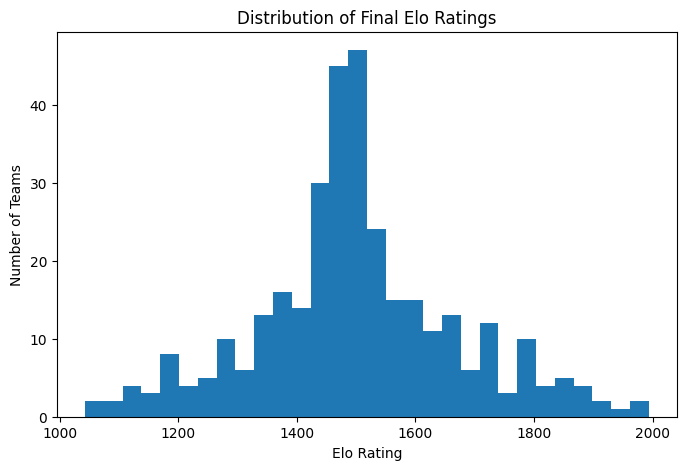

In [131]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(final_elo["elo"], bins=30)

plt.title("Distribution of Final Elo Ratings")

plt.xlabel("Elo Rating")

plt.ylabel("Number of Teams")

plt.show()

Distribusi Elo menunjukkan bahwa sebagian besar tim berada di sekitar rating tengah, sedangkan hanya sedikit tim yang memiliki Elo sangat tinggi maupun sangat rendah.

Pola ini sesuai dengan karakteristik sistem Elo, di mana perubahan rating antar tim bersifat relatif sehingga distribusi cenderung tetap terpusat.

## 8. Save

In [132]:
# simpan dataset hasil Elo Rating
elo_df.to_csv(
    "../data/processed/elo_features.csv",
    index=False
)

In [133]:
elo_df.shape

(49433, 9)

## 9. Elo Rating Summary 
Tahap **Elo Rating Engine** berhasil membangun sistem Elo Rating yang menghitung kekuatan relatif setiap tim nasional berdasarkan seluruh riwayat pertandingan internasional secara kronologis.

Seluruh tim diinisialisasi dengan Elo awal sebesar **1500**, kemudian rating diperbarui setelah setiap pertandingan menggunakan kombinasi **Expected Score**, **Actual Score**, dan **K-Factor**. Proses pembaruan dilakukan secara berurutan sehingga setiap pertandingan hanya memanfaatkan informasi yang tersedia sebelum pertandingan dimulai dan sepenuhnya terhindar dari *future data leakage*. 

Notebook ini menghasilkan empat kolom baru, yaitu `home_elo_before`, `away_elo_before`, `home_elo_after`, dan `away_elo_after`. Di antaranya, `home_elo_before` dan `away_elo_before` akan digunakan sebagai fitur prediktif pada tahap pemodelan berikutnya, sedangkan dua kolom lainnya disimpan sebagai dokumentasi perkembangan rating sekaligus memudahkan proses validasi dan analisis Elo Rating. 

Hasil akhir notebook disimpan sebagai `elo_features.csv`, yang menggabungkan baseline features, historical features, serta Elo Rating menjadi sebuah dataset yang lebih kaya informasi. Dataset ini akan digunakan pada tahap **Elo Modeling** untuk mengevaluasi apakah representasi kekuatan tim melalui Elo Rating mampu meningkatkan performa prediksi dibandingkan Historical Modeling.